In [ ]:
!pip install segmentation-models-pytorch torch torchvision nibabel tqdm -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 6.4 MB/s eta 0:00:00


In [ ]:
import os, json, random, time, copy, gc
from collections import defaultdict
import csv

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import segmentation_models_pytorch as smp
import matplotlib.pyplot as plt
from tqdm import tqdm

# ── Reproducibility ──────────────────────────────────────────────────────────
# deterministic=True: bitwise-identical results across runs (same GPU)
# benchmark=False: no auto-selection of fastest non-det cuDNN algorithm
torch.backends.cudnn.benchmark    = False
torch.backends.cudnn.deterministic = True


def set_global_seed(seed: int) -> None:
    """Set all RNG seeds for full reproducibility."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def seed_worker(worker_id: int) -> None:
    """Per-worker seed for DataLoader — prevents correlated augmentation."""
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)
    torch.manual_seed(worker_seed)


DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if torch.cuda.is_available():
    vram_gb = torch.cuda.get_device_properties(0).total_memory / 1024**3

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
print("Google Drive mounted!")

Mounted at /content/drive
Google Drive mounted!


In [ ]:
DRIVE_ROOT     = "/content/drive/MyDrive/Multi-Atlas_Labeling_Beyond_the_Cranial_Vault"
IMAGES_2D_DIR  = f"{DRIVE_ROOT}/data/processed/images"
MASKS_2D_DIR   = f"{DRIVE_ROOT}/data/processed/masks"
METADATA_PATH  = f"{DRIVE_ROOT}/data/processed/metadata.json"
CHECKPOINT_DIR = f"{DRIVE_ROOT}/checkpoints_baseline"
LOG_DIR        = f"{DRIVE_ROOT}/logs_baseline"
SPLIT_PATH     = f"{DRIVE_ROOT}/data/processed/volume_split.json"

os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(LOG_DIR, exist_ok=True)

IGNORE_INDEX = 255

TRAIN_CFG = {
    "batch_size"  : 16,
    "lr"          : 3e-4,
    "n_epochs"    : 50,
    "save_every"  : 10,
    "num_workers" : 2,
    "loss_alpha"  : 0.5,
    "encoder"     : "resnet34",
    "pretrained"  : "imagenet",
    "num_classes" : 14,
    "seed"        : 42,
}

# ── LwF Hyperparameters ──────────────────────────────────────────────────────
# [CANONICAL LwF] alpha weights KD loss relative to seg loss.
# T=2 is standard (Li & Hoiem 2016). Higher T → softer targets → more gradient signal.
LWF_ALPHA       = 1.0    # Canonical LwF: lambda_o = 1.0 (Li & Hoiem 2016)
LWF_TEMPERATURE = 2.0    # Tune: 1.0 (hard) | 2.0 (standard) | 4.0 (very soft)
CIL_EVAL_EVERY  = 10     # Run CIL eval every N epochs (uses val set — not test)

set_global_seed(TRAIN_CFG["seed"])

print("Config loaded:")
print(f"  LwF alpha       : {LWF_ALPHA}")
print(f"  LwF temperature : {LWF_TEMPERATURE}")
for k, v in TRAIN_CFG.items():
    print(f"  {k:15s}: {v}")


Config loaded:
  LwF alpha       : 1.0
  LwF temperature : 2.0
  batch_size     : 16
  lr             : 0.0003
  n_epochs       : 50
  save_every     : 10
  num_workers    : 2
  loss_alpha     : 0.5
  encoder        : resnet34
  pretrained     : imagenet
  num_classes    : 14
  seed           : 42


## Step 2 — Task Definitions, Dataset, Model, Loss, Metrics

In [ ]:
TASK_ORGANS = {
    1: [6, 7, 1],
    2: [2, 3, 11],
    3: [8, 9, 10],
    4: [4, 5, 12, 13],
}
ORGAN_NAMES = {
    0:  "Background",
    1:  "Spleen (Lach)",
    2:  "Right Kidney (Than P)",
    3:  "Left Kidney (Than T)",
    4:  "Gallbladder (Tui mat)",
    5:  "Esophagus (Thuc quan)",
    6:  "Liver (Gan)",
    7:  "Stomach (Da day)",
    8:  "Aorta (DM chu)",
    9:  "IVC (TM chu duoi)",
    10: "Portal Vein (TM cua)",
    11: "Pancreas (Tuy)",
    12: "Right Adrenal (TTT P)",
    13: "Left Adrenal (TTT T)",
}
ALL_PAST_ORGANS = {
    1: [6, 7, 1],
    2: [6, 7, 1, 2, 3, 11],
    3: [6, 7, 1, 2, 3, 11, 8, 9, 10],
    4: [6, 7, 1, 2, 3, 11, 8, 9, 10, 4, 5, 12, 13],
}

TASK_ORDER = [1, 2, 3, 4]
assert list(TASK_ORGANS.keys()) == TASK_ORDER, "Task order mismatch"

print("Task definitions:")
for task_id, organs in TASK_ORGANS.items():
    names = [ORGAN_NAMES[o] for o in organs]
    print(f"  Task {task_id}: {names}")

Task definitions:
  Task 1: ['Liver (Gan)', 'Stomach (Da day)']
  Task 2: ['Spleen (Lach)', 'Right Kidney (Than P)', 'Left Kidney (Than T)', 'Aorta (DM chu)']
  Task 3: ['Gallbladder (Tui mat)', 'IVC (TM chu duoi)', 'Portal Vein (TM cua)', 'Pancreas (Tuy)']
  Task 4: ['Esophagus (Thuc quan)', 'Right Adrenal (TTT P)', 'Left Adrenal (TTT T)']


In [ ]:
# ── Helper utilities ────────────────────────────────────────────────────────

def remap_mask_for_task(mask_npy, task_id, ignore_index=255):
    """Keep only current-task organ pixels; mark rest as ignore_index."""
    task_organs = TASK_ORGANS[task_id]
    new_mask = np.full_like(mask_npy, fill_value=ignore_index, dtype=np.uint8)
    new_mask[mask_npy == 0] = 0          # background always visible
    for organ_id in task_organs:
        new_mask[mask_npy == organ_id] = organ_id
    return new_mask


def get_slices_for_task(metadata, task_id):
    task_organs = set(TASK_ORGANS[task_id])
    return [r for r in metadata if task_organs & set(r["organs_present"])]


def log_vram(label=""):
    if not torch.cuda.is_available():
        return
    used  = torch.cuda.memory_allocated() / 1024**3
    total = torch.cuda.get_device_properties(0).total_memory / 1024**3
    pct   = used / total * 100
    tag   = "WARNING" if pct > 85 else "OK"
    print(f"   {tag} VRAM {label}: {used:.2f}/{total:.1f} GB ({pct:.0f}%)")


def force_cleanup():
    """Aggressively release VRAM — call after deleting teacher."""
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.synchronize()


# ── 3-way volume-level split ─────────────────────────────────────────────────
def create_three_way_split(metadata, val_ratio=0.10, test_ratio=0.30, seed=42):
    """
    Create strict Train/Val/Test split at VOLUME level (not slice level).

    Slices from the same volume must never appear in more than one split.
    Violating this would constitute data leakage.

    Protocol:
      Train (60%): gradient updates only
      Val   (10%): checkpoint selection — never reported in paper
      Test  (30%): final metric reporting — SEALED during all training
    """
    from collections import defaultdict as _dd
    vol_to_recs = _dd(list)
    for rec in metadata:
        vol_to_recs[rec["volume_id"]].append(rec)

    vol_ids = sorted(vol_to_recs.keys())   # sorted for determinism
    rng = random.Random(seed)
    rng.shuffle(vol_ids)

    n_total = len(vol_ids)
    n_test  = max(1, int(n_total * test_ratio))
    n_val   = max(1, int(n_total * val_ratio))
    # Ensure no overlap
    assert n_test + n_val < n_total, "test+val >= total volumes — increase dataset size"

    test_vols  = set(vol_ids[:n_test])
    val_vols   = set(vol_ids[n_test : n_test + n_val])
    train_vols = set(vol_ids[n_test + n_val :])

    # Leakage assertion
    assert not (train_vols & val_vols), "Train/Val overlap!"
    assert not (train_vols & test_vols), "Train/Test overlap!"
    assert not (val_vols & test_vols), "Val/Test overlap!"

    print(f"  [3-way split] Total volumes : {n_total}")
    print(f"  [3-way split] Train={len(train_vols)}  Val={len(val_vols)}  Test={len(test_vols)}")
    print(f"  [3-way split] Val  volumes : {sorted(val_vols)}")
    print(f"  [3-way split] Test volumes : {sorted(test_vols)}")

    train_records = [r for vid in vol_ids if vid in train_vols for r in vol_to_recs[vid]]
    val_records   = [r for vid in vol_ids if vid in val_vols   for r in vol_to_recs[vid]]
    test_records  = [r for vid in vol_ids if vid in test_vols  for r in vol_to_recs[vid]]
    return train_vols, val_vols, test_vols, train_records, val_records, test_records


def load_volume_split(split_path, metadata):
    """
    Load 3-way split from JSON.
    If 'test_vol_ids' key is absent (legacy 2-way format), RAISE error.
    Fallback test=val is forbidden — it would invalidate final reporting.
    """
    with open(split_path, "r") as f:
        split = json.load(f)

    train_vol_ids = set(split["train_vol_ids"])
    val_vol_ids   = set(split["val_vol_ids"])

    if "test_vol_ids" not in split:
        raise ValueError(
            f"volume_split.json at {split_path} has no 'test_vol_ids' key.\n"
            "This notebook requires a strict 3-way split. "
            "Delete the file to auto-create a new 3-way split, or manually add 'test_vol_ids'."
        )
    test_vol_ids = set(split["test_vol_ids"])

    # Verify no leakage
    assert not (train_vol_ids & val_vol_ids), "LEAKAGE: Train/Val overlap in split file!"
    assert not (train_vol_ids & test_vol_ids), "LEAKAGE: Train/Test overlap in split file!"
    assert not (val_vol_ids & test_vol_ids), "LEAKAGE: Val/Test overlap in split file!"

    print(f"  [load_volume_split] {split_path}")
    print(f"  Seed={split.get('seed','?')}, created_by={split.get('created_by','?')}")
    print(f"  Train={len(train_vol_ids)} | Val={len(val_vol_ids)} | Test={len(test_vol_ids)}")

    train_records = [r for r in metadata if r["volume_id"] in train_vol_ids]
    val_records   = [r for r in metadata if r["volume_id"] in val_vol_ids]
    test_records  = [r for r in metadata if r["volume_id"] in test_vol_ids]
    return train_vol_ids, val_vol_ids, test_vol_ids, train_records, val_records, test_records


print("Helpers ready!")

Helpers ready!


In [ ]:
class BTCVDataset(Dataset):
    """BTCV true 2.5D slice dataset.

    CT .npy files must be true 2.5D arrays: either (3,H,W) or (H,W,3).
    Mask .npy files are (H,W) uint8/int labels in the global BTCV taxonomy.
    """
    def __init__(self, records, images_dir, masks_dir,
                 task_id=None, augment=False, ignore_index=255):
        self.records      = records
        self.images_dir   = images_dir
        self.masks_dir    = masks_dir
        self.task_id      = task_id
        self.augment      = augment
        self.ignore_index = ignore_index

        n_slices = records[0].get("num_slices", TRAIN_CFG["num_slices"]) if records else "?"
        mode_str = "train+aug" if augment else "eval"
        print(f"  BTCVDataset [{mode_str}]: "
              f"{len(records)} slices, task_id={task_id}, num_slices={n_slices}")

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        rec      = self.records[idx]
        ct_npy   = np.load(os.path.join(self.images_dir, rec["filename"]))
        mask_npy = np.load(os.path.join(self.masks_dir,  rec["filename"]))

        ct_npy = ensure_ct_25d_array(ct_npy)
        mask_npy = np.asarray(mask_npy)
        if mask_npy.ndim != 2:
            raise ValueError(f"Expected 2D mask array, got shape={mask_npy.shape}")

        if self.task_id is not None:
            mask_npy = remap_mask_for_task(mask_npy, self.task_id, self.ignore_index)
        else:
            mask_npy = mask_npy.astype(np.uint8, copy=False)

        if self.augment:
            ct_npy, mask_npy = self._augment(ct_npy, mask_npy)

        ct_tensor = torch.from_numpy(np.ascontiguousarray(ct_npy)).float()
        mask_tensor = torch.from_numpy(np.ascontiguousarray(mask_npy).astype(np.int64))

        assert ct_tensor.shape[0] == TRAIN_CFG["in_channels"] == 3, \
            f"ct_tensor must be true 2.5D (3,H,W), got {tuple(ct_tensor.shape)}"
        assert mask_tensor.ndim == 2, f"mask_tensor must be (H,W), got {tuple(mask_tensor.shape)}"
        assert ct_tensor.shape[1:] == mask_tensor.shape, \
            f"CT/mask spatial shape mismatch: {tuple(ct_tensor.shape)} vs {tuple(mask_tensor.shape)}"
        assert ct_tensor.shape[1] % 32 == 0 and ct_tensor.shape[2] % 32 == 0, \
            f"H,W must be divisible by 32, got {tuple(ct_tensor.shape[1:])}"

        return ct_tensor, mask_tensor

    def _augment(self, ct, mask):
        """
        Safe augmentation cho CT có Left/Right labels.
        ct   : (H, W, N) float32 [0,1]
        mask : (H, W)    uint8   [0-13]; 255 only if invalid pixels are introduced elsewhere
        """
        from scipy.ndimage import zoom

        # ct arrives as (C, H, W). Transpose to (H, W, C) for augmentation.
        ct = np.transpose(ct, (1, 2, 0))

        # ── 1. Intensity shift (p=0.5) ──────────────────────────────
        if np.random.rand() < 0.5:
            shift = np.random.uniform(-0.05, 0.05)
            ct = np.clip(ct + shift, 0.0, 1.0).astype(np.float32)

        # ── 2. Contrast scaling (p=0.5) ─────────────────────────────
        if np.random.rand() < 0.5:
            scale = np.random.uniform(0.95, 1.05)
            mean = ct.mean()
            ct = np.clip((ct - mean) * scale + mean,0.0,1.0).astype(np.float32)

        # ── 3. Random zoom-in crop (p=0.4) ──────────────────────────
        if np.random.rand() < 0.3:
            H, W, C = ct.shape # Get correct H, W from channel-last CT
            scale = np.random.uniform(0.9, 1.0)
            new_H = int(H * scale)
            new_W = int(W * scale)
            top = np.random.randint(0, H - new_H + 1)
            left = np.random.randint(0, W - new_W + 1)
            ct_crop = ct[top:top+new_H, left:left+new_W]
            mask_crop = mask[top:top+new_H, left:left+new_W]
            factor = H / new_H

            ct = zoom(ct_crop,(factor, factor, 1),order=1).astype(np.float32)
            mask = zoom(mask_crop,(factor, factor),order=0).astype(np.uint8)

        # ── 4. Small rotation ±10° (p=0.4) ──────────────────────────
        if np.random.rand() < 0.3:
            angle = np.random.uniform(-5, 5)
            rotated_channels = []
            for i in range(ct.shape[2]): # Iterate over channels (C)
                ch = scipy_rotate(
                    ct[:, :, i], # Select a single channel (H, W)
                    angle,
                    reshape=False,
                    order=1,
                    cval=0.0
                )
                rotated_channels.append(ch.astype(np.float32))

            ct = np.stack(rotated_channels, axis=-1) # Stack back to (H, W, C)

            mask = scipy_rotate(
                mask,
                angle,
                reshape=False,
                order=0,
                cval=0  # Preserve existing augmentation protocol; padding is treated as background.
            ).astype(np.uint8)

        # Transpose ct back to channel-first (C, H, W) before returning
        ct = np.transpose(ct, (2, 0, 1))

        return ct, mask

print("BTCVDataset ready!")

BTCVDataset ready!


In [ ]:
# ── Model ────────────────────────────────────────────────────────────────────
def build_unet(num_classes=14, encoder="resnet34", pretrained="imagenet"):
    return smp.UnetPlusPlus(
        encoder_name=encoder,
        encoder_weights=pretrained,
        in_channels=3,
        classes=num_classes,
        activation=None,
    )


# ── Segmentation Loss ─────────────────────────────────────────────────────────
class TaskDiceLoss(nn.Module):
    def __init__(self, smooth=1e-5, ignore_index=255):
        super().__init__()
        self.smooth       = smooth
        self.ignore_index = ignore_index

    def forward(self, logits, target, task_organs):
        probs = F.softmax(logits, dim=1)
        valid = (target != self.ignore_index).float()
        dice_list = []
        for c in task_organs:
            pred_c = probs[:, c] * valid
            true_c = (target == c).float() * valid
            intsec = (pred_c * true_c).sum(dim=(1, 2))
            union  = pred_c.sum(dim=(1, 2)) + true_c.sum(dim=(1, 2))
            dice   = (2 * intsec + self.smooth) / (union + self.smooth)
            dice_list.append(1 - dice.mean())
        return torch.stack(dice_list).mean()


class CombinedLoss(nn.Module):
    def __init__(self, alpha=0.5, ignore_index=255):
        super().__init__()
        self.alpha        = alpha
        self.ignore_index = ignore_index
        self.ce           = nn.CrossEntropyLoss(ignore_index=ignore_index)
        self.dice         = TaskDiceLoss(ignore_index=ignore_index)

    def forward(self, logits, target, task_organs):
        loss_ce   = self.ce(logits, target)
        loss_dice = self.dice(logits, target, task_organs)
        total     = self.alpha * loss_ce + (1 - self.alpha) * loss_dice
        return total, loss_ce.item(), loss_dice.item()


# ── Metrics ───────────────────────────────────────────────────────────────────
def format_dice_table(dice_dict, task_organs, epoch=None):
    ep_str = f"{epoch:6d}" if epoch is not None else " " * 6
    print(f"\n  {ep_str}  {'Organ':30s}  {'Dice':>8}  {'Status':>8}")
    print("  " + "-" * 58)
    valid_dices = []
    for organ_id in task_organs:
        dice = dice_dict.get(organ_id, float('nan'))
        name = ORGAN_NAMES.get(organ_id, f"Organ {organ_id}")
        if not np.isnan(dice):
            valid_dices.append(dice)
            status = "Good" if dice >= 0.7 else ("Fair" if dice >= 0.5 else "Poor")
            print(f"  {ep_str}  {name:30s}  {dice:8.4f}  {status}")
        else:
            print(f"  {ep_str}  {name:30s}  {'N/A':>8}  (absent)")
    if valid_dices:
        mean_dice = float(np.mean(valid_dices)) if valid_dices else float("nan")
        print("  " + "=" * 58)
        print(f"  {ep_str}  {'Mean Dice':30s}  {mean_dice:8.4f}")
    return np.mean(valid_dices) if valid_dices else 0.0

print("Model + Loss + Metrics ready!")

Model + Loss + Metrics ready!


## Step 3 — Canonical LwF Core

### Thiết kế Teacher-Student
```
Teacher: model state IMMEDIATELY after Task t-1 finishes
         → frozen: .eval() + requires_grad=False
         → inference: always inside torch.no_grad()
         → snapshot: deepcopy BEFORE optimizer step of Task t

Student: model being trained on Task t
         → only learns from current-task data
         → distilled to imitate teacher's output on current-task inputs

Loss = L_seg(student(x), y_current)
     + alpha * L_KD(student(x) || teacher(x))
```

### ⚠ Background Shift — Known Limitation
Teacher's background class absorbs probability mass from "future" organs
(organs in Tasks t+1, t+2 that teacher hasn't seen yet). This is inherent
to all LwF-based CIL segmentation without special handling.
**Fix**: MiB (Cermelli et al., CVPR 2020). Note this in paper Section 4.

### ⚠ Multi-Teacher NOT Used (Canonical Design)
Previous versions merged multiple teachers for Task 3+. This is a deviation
from canonical LwF (Li & Hoiem 2016), which uses a SINGLE teacher (the
model from the immediately preceding task). This notebook restores the
canonical single-teacher design for all tasks.

In [ ]:
# ── KD Loss — Canonical LwF ─────────────────────────────────────────────────
class KDLoss(nn.Module):
    """
    Knowledge Distillation loss for canonical LwF.

    Li & Hoiem LwF uses modified cross-entropy on temperature-scaled teacher
    and student probabilities:
        L_KD = -mean(sum(softmax(teacher/T) * log_softmax(student/T)))

    No T^2 rescaling is applied in the original LwF formulation.
    """
    def __init__(self, temperature: float = 2.0):
        super().__init__()
        self.T = temperature

    def forward(
        self,
        student_logits: torch.Tensor,     # (B, C, H, W)
        teacher_logits: torch.Tensor,     # (B, C, H, W)
        distill_channels=None,            # old-task output channels
        valid_mask: torch.Tensor = None,  # (B, H, W) boolean
    ) -> torch.Tensor:
        student_logits = student_logits.float()
        teacher_logits = teacher_logits.float()

        if distill_channels is not None:
            student_logits = student_logits[:, distill_channels, :, :]
            teacher_logits = teacher_logits[:, distill_channels, :, :]

        student_log_prob = F.log_softmax(student_logits / self.T, dim=1)
        teacher_prob     = F.softmax(teacher_logits / self.T, dim=1)

        ce_pixel = -(teacher_prob * student_log_prob).sum(dim=1)

        if valid_mask is not None:
            ce_pixel = ce_pixel[valid_mask]

        if ce_pixel.numel() == 0:
            return student_logits.new_zeros(1, requires_grad=True).squeeze()

        return ce_pixel.mean()


print("KDLoss ready!")
print(f"  Temperature      = {LWF_TEMPERATURE}")
print("  T² scaling       = disabled (canonical LwF)")
print("  KD formula       = modified cross-entropy")
print("  KD scope         = old-task output channels only")

KDLoss ready!
  Temperature      = 2.0
  T² scaling       = disabled (canonical LwF)
  KD formula       = modified cross-entropy
  KD scope         = old-task output channels only


## Step 4 — LwFTrainer

In [ ]:
class LwFTrainer:
    """
    Canonical LwF Trainer for class-incremental segmentation.

    Key invariants (verified internally):
    1. Teacher is always in .eval() mode with requires_grad=False
    2. Teacher inference is always inside torch.no_grad()
    3. Teacher is a deepcopy snapshot — not the student being updated
    4. KD uses LIVE teacher inference, not pre-cached/stale logits
    5. Val loader used for checkpoint selection only (not test)
    """

    def __init__(self, model, optimizer, criterion, kd_criterion,
                 scheduler, device, task_id, teacher_model,
                 checkpoint_dir, log_dir,
                 lwf_alpha=1.0, save_every=10, ignore_index=255,
                 cil_eval_every=10):

        self.model          = model
        self.optimizer      = optimizer
        self.criterion      = criterion       # CombinedLoss (segmentation)
        self.kd_criterion   = kd_criterion    # KDLoss
        self.scheduler      = scheduler
        self.device         = device
        self.task_id        = task_id
        self.task_organs    = TASK_ORGANS[task_id]
        self.all_learned    = ALL_PAST_ORGANS[task_id]
        self.checkpoint_dir = checkpoint_dir
        self.log_dir        = log_dir
        self.lwf_alpha      = lwf_alpha
        self.save_every     = save_every
        self.ignore_index   = ignore_index
        self.cil_eval_every = cil_eval_every

        # ── Teacher setup ──────────────────────────────────────────────────
        # [CANONICAL] Teacher is None for Task 1 (no previous task).
        # For Task 2+: teacher is a FROZEN DEEPCOPY of model after Task t-1.
        self.teacher = teacher_model
        self.old_organs  = []
        self.distill_channels = []

        if self.teacher is not None:
            # Compute old_organs from tasks before current
            for tid in range(1, task_id):
                self.old_organs.extend(TASK_ORGANS[tid])

            self.distill_channels = [0] + self.old_organs

            # Freeze teacher — assert correctness
            self.teacher.eval()
            for p in self.teacher.parameters():
                p.requires_grad = False
            # Verify freeze
            assert all(not p.requires_grad for p in self.teacher.parameters()), \
                "CRITICAL: Teacher has unfrozen parameters — canonical LwF violated!"
            print(f"  [LwF] Teacher FROZEN: {len(list(self.teacher.parameters()))} params, "
                  f"all requires_grad=False ✓")
        else:
            assert task_id == 1, "teacher_model=None only valid for Task 1"
            print(f"  [LwF] Task 1: no teacher (no previous task) ✓")

        self.best_val_dice = 0.0
        self.best_cil_dice = 0.0
        self.miou_history  = []   # mIoU(All) after each task, for avg mIoU
        self.history = {
            "train_loss": [], "val_loss": [], "val_dice": [], "lr": [],
            "seg_loss": [], "kd_loss": [], "kd_seg_ratio": [], "cil_dice": [],
        }

        self.use_amp = (device.type == 'cuda')
        self.scaler  = torch.amp.GradScaler('cuda', enabled=self.use_amp)

        print(f"  LwFTrainer: Task {task_id}, "
              f"organs={[ORGAN_NAMES[o] for o in self.task_organs]}")
        print(f"  Old organs protected by KD: {[ORGAN_NAMES[o] for o in self.old_organs]}")
        print(f"  KD distill channels: {self.distill_channels}")
        print(f"  Alpha={lwf_alpha}, T={kd_criterion.T}, AMP={self.use_amp}")

    # ── Training ──────────────────────────────────────────────────────────────
    def train_epoch(self, loader):
        """
        Train 1 epoch.

        [CANONICAL] Teacher inference (if teacher exists) happens INSIDE
        torch.no_grad(), strictly separated from student's computation graph.
        Teacher is never updated.
        """
        self.model.train()
        total_loss = total_seg = total_kd = 0.0
        n_batches = 0

        for ct_batch, mask_batch in loader:
            ct_batch   = ct_batch.to(self.device, non_blocking=True)
            mask_batch = mask_batch.to(self.device, non_blocking=True)
            # ── Tạo mask cho segmentation loss (remap)
            mask_seg = mask_batch.clone()
            # Đánh dấu các pixel không phải background (0) và không thuộc cơ quan task hiện tại
            ignore_mask = torch.ones_like(mask_seg, dtype=torch.bool)
            for oid in self.task_organs:
                ignore_mask &= (mask_seg != oid)
            ignore_mask &= (mask_seg != 0)   # background giữ lại
            mask_seg[ignore_mask] = self.ignore_index   # gán ignore

            # ── Mặt nạ cho KD: tất cả pixel hợp lệ TRỪ pixel của task hiện tại ──
            # Vì mask gốc không có 255, hợp lệ là tất cả pixel
            valid_mask = mask_batch != self.ignore_index   # luôn True (nhưng để an toàn)
            new_task_mask = torch.zeros_like(mask_batch, dtype=torch.bool)
            for oid in self.task_organs:
                new_task_mask |= (mask_batch == oid)
            valid_kd_mask = valid_mask & ~new_task_mask  # (B, H, W) bool

            self.optimizer.zero_grad(set_to_none=True)

            with torch.amp.autocast('cuda', enabled=self.use_amp):
                student_logits = self.model(ct_batch)   # (B, 14, H, W)

                # Segmentation loss – dùng mask đã remap
                loss_seg, _, _ = self.criterion(student_logits, mask_seg, self.task_organs)

                # KD loss – nếu có teacher
                loss_kd = torch.zeros(1, device=self.device)
                if self.teacher is not None:
                    with torch.no_grad():
                        teacher_logits = self.teacher(ct_batch)
                    loss_kd = self.kd_criterion(
                        student_logits,
                        teacher_logits,
                        distill_channels=self.distill_channels,
                        valid_mask=valid_kd_mask
                    )

                loss = loss_seg + self.lwf_alpha * loss_kd

            self.scaler.scale(loss).backward()
            self.scaler.unscale_(self.optimizer)
            torch.nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=1.0)
            self.scaler.step(self.optimizer)
            self.scaler.update()

            total_loss += loss.item()
            total_seg  += loss_seg.item()
            total_kd   += loss_kd.item()
            n_batches  += 1

        avg_loss = total_loss / n_batches
        avg_seg  = total_seg  / n_batches
        avg_kd   = total_kd   / n_batches
        ratio    = avg_kd / max(avg_seg, 1e-8)
        return avg_loss, avg_seg, avg_kd, ratio

    # ── Validation ───────────────────────────────────────────────────────────
    @torch.no_grad()
    def validate(self, loader):
        """Validate on current task organs. Used ONLY for checkpoint selection."""
        self.model.eval()
        total_loss = 0.0
        inter = defaultdict(float)
        union = defaultdict(float)

        for ct_batch, mask_batch in loader:
            ct_batch   = ct_batch.to(self.device, non_blocking=True)
            mask_batch = mask_batch.to(self.device, non_blocking=True)
            with torch.amp.autocast('cuda', enabled=self.use_amp):
                logits = self.model(ct_batch)
                loss, _, _ = self.criterion(logits, mask_batch, self.task_organs)
            total_loss += loss.item()

            pred  = torch.argmax(logits, dim=1)
            valid = (mask_batch != self.ignore_index)
            for organ_id in self.task_organs:
                pred_o = (pred      == organ_id) & valid
                true_o = (mask_batch == organ_id) & valid
                inter[organ_id] += (pred_o & true_o).sum().item()
                union[organ_id] += pred_o.sum().item() + true_o.sum().item()

        val_loss = total_loss / len(loader)
        dice_dict = {}
        for organ_id in self.task_organs:
            if union[organ_id] > 0:
                dice_dict[organ_id] = 2 * inter[organ_id] / union[organ_id]
            else:
                dice_dict[organ_id] = float('nan')
        return val_loss, dice_dict

    # ── CIL Evaluation ───────────────────────────────────────────────────────
    @torch.no_grad()
    def evaluate_cil(self, eval_loader):
        """
        Evaluate on ALL organs learned so far.
        eval_loader must use task_id=None (full mask, no remap).

        Returns DSC and IoU dicts split by old/new organs.
        Called during training with VAL loader for checkpoint selection.
        Called in Step 6 with TEST loader for final paper metrics.
        """
        self.model.eval()
        inter      = defaultdict(float)
        dice_denom = defaultdict(float)  # pred_sum + true_sum

        for ct_batch, mask_batch in eval_loader:
            ct_batch   = ct_batch.to(self.device, non_blocking=True)
            mask_batch = mask_batch.to(self.device, non_blocking=True)
            with torch.amp.autocast('cuda', enabled=self.use_amp):
                logits = self.model(ct_batch)
            pred  = torch.argmax(logits, dim=1)
            valid = (mask_batch != self.ignore_index)

            for organ_id in self.all_learned:
                pred_o = (pred      == organ_id) & valid
                true_o = (mask_batch == organ_id) & valid
                inter[organ_id]      += (pred_o & true_o).sum().item()
                dice_denom[organ_id] += pred_o.sum().item() + true_o.sum().item()

        dice_all = {}
        iou_all  = {}
        for organ_id in self.all_learned:
            if dice_denom[organ_id] > 0:
                dice_all[organ_id] = 2.0 * inter[organ_id] / dice_denom[organ_id]
            else:
                dice_all[organ_id] = float('nan')
            union_iou = dice_denom[organ_id] - inter[organ_id]
            iou_all[organ_id] = inter[organ_id] / union_iou if union_iou > 0 else float('nan')

        old_organs = [o for o in self.all_learned if o not in self.task_organs]
        dice_old = {o: dice_all[o] for o in old_organs if o in dice_all}
        dice_new = {o: dice_all[o] for o in self.task_organs if o in dice_all}
        iou_old  = {o: iou_all[o]  for o in old_organs if o in iou_all}
        iou_new  = {o: iou_all[o]  for o in self.task_organs if o in iou_all}

        return dice_all, dice_old, dice_new, iou_all, iou_old, iou_new

    # ── Forgetting ────────────────────────────────────────────────────────────
    def compute_forgetting(self, current_dice, task_baselines):
        """
        Compute per-organ forgetting: baseline_dice - current_dice.

        NaN current_dice → treated as 0.0 (model predicts nothing for that organ).
        Organs with NaN baseline → cannot measure forgetting → skipped with warning.
        """
        forgetting     = {}
        skipped_organs = []

        for organ_id, baseline_dice in task_baselines.items():
            if organ_id in self.task_organs:
                continue  # current task — no forgetting yet

            if np.isnan(baseline_dice):
                skipped_organs.append(organ_id)
                continue

            new_dice = current_dice.get(organ_id, float('nan'))
            if np.isnan(new_dice):
                new_dice = 0.0  # complete forgetting

            forgetting[organ_id] = baseline_dice - new_dice

        valid_fgt = [v for v in forgetting.values() if not np.isnan(v)]
        mean_fgt  = float(np.mean(valid_fgt)) if valid_fgt else 0.0

        if skipped_organs:
            names = [ORGAN_NAMES.get(o, f"Organ {o}") for o in skipped_organs]
            print(f"  [Forgetting] Skipped (no valid baseline): {names}")

        return forgetting, mean_fgt

    # ── Checkpoint ────────────────────────────────────────────────────────────
    def save_checkpoint(self, epoch, val_dice, is_best=False,
                        is_best_cil=False, cil_dice=None):
        state = {
            "epoch"          : epoch,
            "task_id"        : self.task_id,
            "method"         : "CanonicalLwF",
            "seed"           : TRAIN_CFG["seed"],
            "model_state"    : self.model.state_dict(),
            "optimizer_state": self.optimizer.state_dict(),
            "scheduler_state": self.scheduler.state_dict() if self.scheduler else None,
            "val_dice"       : val_dice,
            "best_val_dice"  : self.best_val_dice,
            "best_cil_dice"  : self.best_cil_dice,
            "cil_dice"       : cil_dice,
            "history"        : self.history,
            "train_cfg"      : TRAIN_CFG,
            "lwf_alpha"      : self.lwf_alpha,
            "lwf_temperature": self.kd_criterion.T,
            "kd_mode"        : "canonical_lwf_modified_ce",
            "kd_scope"       : "old_task_outputs_with_background",
            "distill_channels": self.distill_channels,
            "t2_scaling"     : False,
            "rng_state"      : {
                "python": random.getstate(),
                "numpy": np.random.get_state(),
                "torch_cpu": torch.get_rng_state(),
                "torch_cuda": torch.cuda.get_rng_state_all() if torch.cuda.is_available() else None,
            },
        }
        ckpt_path = os.path.join(
            self.checkpoint_dir, f"lwf_task{self.task_id}_epoch{epoch:03d}.pth")
        torch.save(state, ckpt_path)

        if is_best:
            best_path = os.path.join(
                self.checkpoint_dir, f"lwf_task{self.task_id}_best.pth")
            torch.save(state, best_path)
            print(f"     ✓ Best val checkpoint! Dice={val_dice:.4f}")

        if is_best_cil:
            best_cil_path = os.path.join(
                self.checkpoint_dir, f"lwf_task{self.task_id}_best_cil.pth")
            torch.save(state, best_cil_path)
            print(f"     ✓ Best CIL checkpoint! CIL Dice={cil_dice:.4f}")

    # ── Main Training Loop ────────────────────────────────────────────────────
    def fit(self, train_loader, val_loader, n_epochs, start_epoch=1,
            val_eval_loader=None, task_baselines=None):
        """
        Main training loop.

        train_loader: BTCVDataset with task_id=current (augmented)
        val_loader:   BTCVDataset with task_id=current (no augment) — for seg loss tracking
        val_eval_loader: BTCVDataset with task_id=None (full mask) — for CIL eval on val set
                         Used ONLY for checkpoint selection (best_cil). Never reported in paper.

        [CANONICAL] Teacher is evaluated inside train_epoch per batch.
        No pre-cached targets. Teacher is frozen throughout.
        """
        print(f"\n{'='*65}")
        print(f"  [LwF] Task {self.task_id} — "
              f"{[ORGAN_NAMES[o] for o in self.task_organs]}")
        if self.teacher is not None:
            print(f"  KD: alpha={self.lwf_alpha}, T={self.kd_criterion.T}")
            print(f"  Old organs: {[ORGAN_NAMES[o] for o in self.old_organs]}")
        else:
            print(f"  No KD (Task 1 — no teacher)")
        print(f"  Epochs: {start_epoch} -> {n_epochs}")
        print(f"{'='*65}")

        for epoch in range(start_epoch, n_epochs + 1):
            t0 = time.time()

            train_loss, seg_loss, kd_loss, kd_ratio = self.train_epoch(train_loader)
            val_loss, dice_dict = self.validate(val_loader)

            if self.scheduler:
                self.scheduler.step(val_loss)

            current_lr = self.optimizer.param_groups[0]['lr']
            mean_dice  = float(np.nanmean(list(dice_dict.values())))
            elapsed    = time.time() - t0

            # ── CIL eval on VAL set (checkpoint selection only) ───────────
            cil_overall = None
            is_best_cil = False
            do_cil = (val_eval_loader is not None
                      and self.task_id > 1
                      and (epoch % self.cil_eval_every == 0 or epoch == n_epochs))
            if do_cil:
                (dice_all, dice_old, dice_new,
                 iou_all, iou_old, iou_new) = self.evaluate_cil(val_eval_loader)
                all_valid = [v for v in dice_all.values() if not np.isnan(v)]
                cil_overall = np.mean(all_valid) if all_valid else 0.0
                if cil_overall > self.best_cil_dice:
                    self.best_cil_dice = cil_overall
                    is_best_cil = True
                old_mean = float(np.nanmean(list(dice_old.values()))) if dice_old else 0.0
                miou_now = float(np.nanmean(list(iou_all.values()))) if iou_all else 0.0
                if task_baselines:
                    _, mean_fgt = self.compute_forgetting(dice_all, task_baselines)
                else:
                    mean_fgt = 0.0
                print(f"  >> CIL [VAL]: DSC_all={cil_overall:.4f} | "
                      f"DSC_old={old_mean:.4f} | mIoU={miou_now:.4f} | "
                      f"fgt={mean_fgt:+.4f}"
                      f"{'  [NEW BEST CIL]' if is_best_cil else ''}")

            # ── History ───────────────────────────────────────────────────
            self.history["train_loss"].append(train_loss)
            self.history["val_loss"].append(val_loss)
            self.history["val_dice"].append(mean_dice)
            self.history["lr"].append(current_lr)
            self.history["seg_loss"].append(seg_loss)
            self.history["kd_loss"].append(kd_loss)
            self.history["kd_seg_ratio"].append(kd_ratio)
            self.history["cil_dice"].append(cil_overall)

            # ── KD ratio warning ──────────────────────────────────────────
            print(f"\n  Epoch {epoch:3d}/{n_epochs} ({elapsed:.0f}s) | LR={current_lr:.2e}")
            if self.teacher is not None:
                print(f"  Train: total={train_loss:.4f} "
                      f"(seg={seg_loss:.4f}, kd={kd_loss:.4f}, kd/seg={kd_ratio:.3f})")
                if kd_ratio < 0.1:
                    print(f"  [WARN] kd/seg={kd_ratio:.3f} < 0.1 — KD too weak, consider increasing alpha")
                elif kd_ratio > 10.0:
                    print(f"  [WARN] kd/seg={kd_ratio:.3f} > 10.0 — KD dominates, consider decreasing alpha")
            else:
                print(f"  Train: total={train_loss:.4f} (seg only, no KD for Task 1)")
            print(f"  Val  : loss={val_loss:.4f} | Mean Dice={mean_dice:.4f}")
            format_dice_table(dice_dict, self.task_organs, epoch=epoch)
            log_vram(f"epoch {epoch}")

            is_best = mean_dice > self.best_val_dice
            if is_best:
                self.best_val_dice = mean_dice
            if epoch % self.save_every == 0 or is_best or is_best_cil:
                self.save_checkpoint(epoch, mean_dice, is_best, is_best_cil, cil_overall)

        self._save_log()
        print(f"\n{'='*65}")
        print(f"  [LwF] Task {self.task_id} done! Best Val={self.best_val_dice:.4f}")
        if self.task_id > 1:
            print(f"  Best CIL (val set) = {self.best_cil_dice:.4f}")
        print(f"{'='*65}")

    # ── Logging ───────────────────────────────────────────────────────────────
    def _save_log(self):
        log_path = os.path.join(self.log_dir, f"lwf_task{self.task_id}_history.csv")
        with open(log_path, 'w', newline='') as f:
            fieldnames = ["epoch", "train_loss", "val_loss", "val_dice", "lr",
                          "seg_loss", "kd_loss", "kd_seg_ratio", "cil_dice"]
            writer = csv.DictWriter(f, fieldnames=fieldnames)
            writer.writeheader()
            for i in range(len(self.history["train_loss"])):
                writer.writerow({
                    "epoch"       : i + 1,
                    "train_loss"  : self.history["train_loss"][i],
                    "val_loss"    : self.history["val_loss"][i],
                    "val_dice"    : self.history["val_dice"][i],
                    "lr"          : self.history["lr"][i],
                    "seg_loss"    : self.history["seg_loss"][i],
                    "kd_loss"     : self.history["kd_loss"][i],
                    "kd_seg_ratio": self.history["kd_seg_ratio"][i],
                    "cil_dice"    : self.history["cil_dice"][i]
                        if self.history["cil_dice"][i] is not None else "",
                })
        print(f"   Log saved: {log_path}")


## Step 5 — Data Split & Training

In [ ]:
# ── Metadata + Volume Split ──────────────────────────────────────────────────
assert callable(load_volume_split), "run Helpers cell first"
assert callable(create_three_way_split), "run Helpers cell first"

with open(METADATA_PATH, "r") as f:
    metadata = json.load(f)

if os.path.exists(SPLIT_PATH):
    print("Found volume_split.json — loading shared split")
    (train_vol_ids, val_vol_ids, test_vol_ids,
     train_records_all, val_records_all, test_records_all) = \
        load_volume_split(SPLIT_PATH, metadata)
else:
    print("volume_split.json not found — creating 3-way split")
    (train_vol_ids, val_vol_ids, test_vol_ids,
     train_records_all, val_records_all, test_records_all) = \
        create_three_way_split(
            metadata,
            val_ratio  = 0.10,
            test_ratio = 0.30,
            seed       = TRAIN_CFG["seed"],
        )
    split_to_save = {
        "train_vol_ids": sorted(train_vol_ids),
        "val_vol_ids"  : sorted(val_vol_ids),
        "test_vol_ids" : sorted(test_vol_ids),
        "seed"         : TRAIN_CFG["seed"],
        "val_ratio"    : 0.10,
        "test_ratio"   : 0.30,
        "created_by"   : "NB04-CanonicalLwF",
    }
    with open(SPLIT_PATH, "w") as f:
        json.dump(split_to_save, f, indent=2)
    print(f"  Saved 3-way split → {SPLIT_PATH}")
    print(f"  Share this file with all other methods for fair comparison.")

print(f"\nSplit summary:")
print(f"  Train : {len(train_records_all)} slices ({len(train_vol_ids)} volumes)")
print(f"  Val   : {len(val_records_all)} slices ({len(val_vol_ids)} volumes) [checkpoint selection]")
print(f"  Test  : {len(test_records_all)} slices ({len(test_vol_ids)} volumes) [SEALED — paper metrics]")

# ── Val CIL loader: task_id=None (full mask) — used INSIDE trainer ───────────
# Passed to trainer.fit() as val_eval_loader for CIL checkpoint selection.
# NEVER used for final paper metrics.
val_eval_loader = DataLoader(
    BTCVDataset(val_records_all, IMAGES_2D_DIR, MASKS_2D_DIR, task_id=None, augment=False),
    batch_size=TRAIN_CFG["batch_size"], shuffle=False,
    num_workers=TRAIN_CFG["num_workers"], pin_memory=False,
)

# ── Test loader: SEALED — only used in Step 6b ───────────────────────────────
# DO NOT pass test_loader to trainer.fit() or any function called during training.
test_loader = DataLoader(
    BTCVDataset(test_records_all, IMAGES_2D_DIR, MASKS_2D_DIR, task_id=None, augment=False),
    batch_size=TRAIN_CFG["batch_size"], shuffle=False,
    num_workers=TRAIN_CFG["num_workers"], pin_memory=False,
)
print(f"\nVal eval loader (val set, checkpoint selection): {len(val_records_all)} slices")
print(f"Test loader (SEALED — Step 6b only)           : {len(test_records_all)} slices")

Found volume_split.json — loading shared split
  [load_volume_split] /content/drive/MyDrive/Multi-Atlas_Labeling_Beyond_the_Cranial_Vault/data/processed/volume_split.json
  Seed=42, created_by=NB04-LwF (fallback — NB02 split not found)
  Train=24 | Val=4 | Test=2

Split summary:
  Train : 1565 slices (24 volumes)
  Val   : 269 slices (4 volumes) [checkpoint selection]
  Test  : 99 slices (2 volumes) [SEALED — paper metrics]

Val eval loader (val set, checkpoint selection): 269 slices
Test loader (SEALED — Step 6b only)           : 99 slices


In [ ]:
# ── Task 1: Load checkpoint (trained in NB02) + CIL eval ────────────────────
print("=" * 65)
print("  TASK 1: Load checkpoint + CIL baseline eval")
print("=" * 65)

model = build_unet(
    num_classes = TRAIN_CFG["num_classes"],
    encoder     = TRAIN_CFG["encoder"],
    pretrained  = TRAIN_CFG["pretrained"],
).to(DEVICE)

task1_ckpt_path = f"{CHECKPOINT_DIR}/task1_best.pth"
if not os.path.exists(task1_ckpt_path):
    raise FileNotFoundError(
        f"Task 1 checkpoint not found: {task1_ckpt_path}\n"
        "Train Task 1 in NB02 first before running LwF."
    )

ckpt = torch.load(task1_ckpt_path, map_location="cpu", weights_only=False)
model.load_state_dict(ckpt["model_state"])
print(f"Loaded Task 1: epoch={ckpt['epoch']}, dice={ckpt.get('best_val_dice', '?'):.4f}")

# ── CIL baseline eval on VAL set ─────────────────────────────────────────────
# This is the Task 1 baseline for forgetting measurement.
# Evaluated on VAL set (consistent with all in-training evaluations).
model.eval()
inter_t1     = defaultdict(float)
dice_denom_t1 = defaultdict(float)

with torch.no_grad():
    for ct_b, mask_b in val_eval_loader:
        ct_b   = ct_b.to(DEVICE, non_blocking=True)
        mask_b = mask_b.to(DEVICE, non_blocking=True)
        with torch.amp.autocast('cuda', enabled=(DEVICE.type == 'cuda')):
            logits = model(ct_b)
        pred  = torch.argmax(logits, dim=1)
        valid = (mask_b != IGNORE_INDEX)
        for oid in TASK_ORGANS[1]:
            pred_o = (pred   == oid) & valid
            true_o = (mask_b == oid) & valid
            inter_t1[oid]      += (pred_o & true_o).sum().item()
            dice_denom_t1[oid] += pred_o.sum().item() + true_o.sum().item()

task1_cil_dice = {}
task1_cil_iou  = {}
for oid in TASK_ORGANS[1]:
    if dice_denom_t1[oid] > 0:
        task1_cil_dice[oid] = 2.0 * inter_t1[oid] / dice_denom_t1[oid]
    else:
        task1_cil_dice[oid] = float('nan')
    union_iou = dice_denom_t1[oid] - inter_t1[oid]
    task1_cil_iou[oid] = inter_t1[oid] / union_iou if union_iou > 0 else float('nan')

print("\nTask 1 baseline (VAL set — for forgetting measurement):")
for oid in TASK_ORGANS[1]:
    d = task1_cil_dice[oid]; iou = task1_cil_iou[oid]
    print(f"  {ORGAN_NAMES[oid]:30s}  DSC={d:.4f}  IoU={iou:.4f}")

valid_dsc_t1 = [v for v in task1_cil_dice.values() if not np.isnan(v)]
valid_iou_t1 = [v for v in task1_cil_iou.values() if not np.isnan(v)]
print(f"  Mean DSC = {np.mean(valid_dsc_t1):.4f} | Mean IoU = {np.mean(valid_iou_t1):.4f}")

# Save Task 1 results
t1_results = {
    "task_id": 1, "method": "CanonicalLwF",
    "eval_split": "val",  # explicitly label split
    "dsc": {"all": round(np.mean(valid_dsc_t1), 4),
            "per_organ": {ORGAN_NAMES[k]: round(v, 4)
                         for k, v in task1_cil_dice.items() if not np.isnan(v)}},
    "miou": {"all": round(np.mean(valid_iou_t1), 4),
             "per_organ": {ORGAN_NAMES[k]: round(v, 4)
                          for k, v in task1_cil_iou.items() if not np.isnan(v)}},
    "forgetting": {"per_organ": {}, "mean": 0.0},
}
with open(f"{LOG_DIR}/lwf_task1_cil_results.json", 'w') as f:
    json.dump(t1_results, f, indent=2)
print(f"Task 1 results saved.")
log_vram("after Task 1 eval")


  TASK 1: Load checkpoint + CIL baseline eval


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

Loaded Task 1: epoch=56, dice=0.9026

Task 1 baseline (VAL set — for forgetting measurement):
  Liver (Gan)                     DSC=0.9021  IoU=0.8216
  Stomach (Da day)                DSC=0.8452  IoU=0.7319
  Mean DSC = 0.8736 | Mean IoU = 0.7767
Task 1 results saved.
   OK VRAM after Task 1 eval: 0.25/14.6 GB (2%)


In [ ]:
# ── Train Tasks 2 → 3 → 4 with Canonical LwF ────────────────────────────────
#
# [CANONICAL LwF PROTOCOL]
# For each task t = 2, 3, 4:
#   1. SNAPSHOT py
#      → this is the EXACT state that needs to be protected
#   2. teacher.eval() + freeze all parameters
#   3. Train student on task-t data with:
#      L = L_seg(student, y_t) + alpha * L_KD(student || teacher)
#      Teacher is queried LIVE per batch inside torch.no_grad()
#   4. Save best_val + best_cil checkpoints (based on VAL set)
#
# No multi-teacher. No pre-cached soft targets.
# Teacher snapshot happens once, right before Task t training starts.

STARTING_TASK = 2   # Change to 3 or 4 to resume from that task

# ── Task baselines for forgetting measurement ─────────────────────────────────
task_baselines = dict(task1_cil_dice)   # {organ_id: dice_after_task_learned}

if STARTING_TASK > 2:
    # Reconstruct baselines from saved JSON files
    for past_tid in range(1, STARTING_TASK):
        cil_path = f"{LOG_DIR}/lwf_task{past_tid}_cil_results.json"
        if os.path.exists(cil_path):
            with open(cil_path) as f:
                past_res = json.load(f)
            for organ_name, dice_val in past_res["dsc"]["per_organ"].items():
                organ_id = next(
                    (k for k, v in ORGAN_NAMES.items() if v == organ_name), None)
                if organ_id is not None and organ_id in TASK_ORGANS.get(past_tid, []):
                    task_baselines[organ_id] = dice_val
    print(f"Baselines reconstructed: {len(task_baselines)} organs")

if STARTING_TASK > 2:
    prev_tid = STARTING_TASK - 1
    cil_p = f"{CHECKPOINT_DIR}/lwf_task{prev_tid}_best_cil.pth"
    val_p = f"{CHECKPOINT_DIR}/lwf_task{prev_tid}_best.pth"
    prev_ckpt_path = cil_p if os.path.exists(cil_p) else val_p
    if not os.path.exists(prev_ckpt_path):
        raise FileNotFoundError(
            f"No checkpoint for Task {prev_tid}: {prev_ckpt_path}"
        )
    prev_state = torch.load(
        prev_ckpt_path,
        map_location="cpu",
        weights_only=False
    )
    model.load_state_dict(prev_state["model_state"])
    print(
        f"Resumed model from Task {prev_tid} "
        f"(epoch {prev_state['epoch']})"
    )
    del prev_state
    gc.collect()
    torch.cuda.empty_cache()


# ── Main loop ────────────────────────────────────────────────────────────────
for task_id in range(STARTING_TASK, 5):

    print(f"\n\n{'#'*70}")
    print(f"#  Canonical LwF — TASK {task_id}")
    print(f"{'#'*70}")

    # ── 1. Snapshot teacher BEFORE task-t training ───────────────────────
    # Teacher = frozen snapshot of model AFTER Task t-1
    # and BEFORE any Task t optimization step.

    teacher_model = build_unet(
        num_classes=TRAIN_CFG["num_classes"],
        encoder=TRAIN_CFG["encoder"],
        pretrained=None,
    ).to(DEVICE)

    # Copy weights from current student model
    teacher_model.load_state_dict(model.state_dict())

    # Freeze teacher completely
    teacher_model.eval()
    teacher_model.requires_grad_(False)

    # Sanity checks
    assert not teacher_model.training, \
        "CRITICAL: Teacher accidentally left in train mode!"

    assert all(not p.requires_grad for p in teacher_model.parameters()), \
        "CRITICAL: Teacher not fully frozen!"

    print(f"Teacher snapshot created from Task {task_id - 1}")

    log_vram("after teacher snapshot")

    # ── 2. Data loaders ───────────────────────────────────────────────────
    task_slices   = get_slices_for_task(metadata, task_id)
    train_records = [r for r in task_slices if r["volume_id"] in train_vol_ids]
    val_records   = [r for r in task_slices if r["volume_id"] in val_vol_ids]

    # Verify no leakage between train and val records
    train_vids_task = {r["volume_id"] for r in train_records}
    val_vids_task   = {r["volume_id"] for r in val_records}
    assert not (train_vids_task & val_vids_task), \
        f"LEAKAGE: Task {task_id} train/val volume overlap!"

    print(f"  Train: {len(train_records)} slices | Val: {len(val_records)} slices")

    g = torch.Generator()
    g.manual_seed(TRAIN_CFG["seed"] + task_id)

    train_loader = DataLoader(
        BTCVDataset(train_records, IMAGES_2D_DIR, MASKS_2D_DIR,
                    task_id=task_id, augment=True),
        batch_size=TRAIN_CFG["batch_size"], shuffle=True,
        num_workers=TRAIN_CFG["num_workers"], pin_memory=False,
        drop_last=True, persistent_workers=False,
        worker_init_fn=seed_worker, generator=g,
    )
    val_loader = DataLoader(
        BTCVDataset(val_records, IMAGES_2D_DIR, MASKS_2D_DIR,
                    task_id=task_id, augment=False),
        batch_size=TRAIN_CFG["batch_size"], shuffle=False,
        num_workers=TRAIN_CFG["num_workers"], pin_memory=False,
        persistent_workers=False,
    )

    # ── 3. Optimizer + scheduler + losses ─────────────────────────────────
    optimizer = torch.optim.AdamW(
        model.parameters(), lr=TRAIN_CFG["lr"], weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=5, min_lr=1e-6)
    seg_criterion = CombinedLoss(
        alpha=TRAIN_CFG["loss_alpha"], ignore_index=IGNORE_INDEX)
    kd_criterion = KDLoss(temperature=LWF_TEMPERATURE)

    # ── 4. Trainer ────────────────────────────────────────────────────────
    trainer = LwFTrainer(
        model           = model,
        optimizer       = optimizer,
        criterion       = seg_criterion,
        kd_criterion    = kd_criterion,
        scheduler       = scheduler,
        device          = DEVICE,
        task_id         = task_id,
        teacher_model   = teacher_model,
        checkpoint_dir  = CHECKPOINT_DIR,
        log_dir         = LOG_DIR,
        lwf_alpha       = LWF_ALPHA,
        save_every      = TRAIN_CFG["save_every"],
        ignore_index    = IGNORE_INDEX,
        cil_eval_every  = CIL_EVAL_EVERY,
    )

    # Load mIoU history from past tasks for accurate avg_miou
    for past_tid in range(1, task_id):
        past_path = f"{LOG_DIR}/lwf_task{past_tid}_cil_results.json"
        if os.path.exists(past_path):
            with open(past_path) as f:
                pr = json.load(f)
            past_miou = pr.get("miou", {}).get("all", None)
            if past_miou is not None:
                trainer.miou_history.append(past_miou)

    # ── 5. Train ──────────────────────────────────────────────────────────
    # val_eval_loader uses VAL set with full mask → CIL checkpoint selection
    # test_loader is NOT passed → test set stays SEALED
    trainer.fit(
        train_loader    = train_loader,
        val_loader      = val_loader,
        n_epochs        = TRAIN_CFG["n_epochs"],
        start_epoch     = 1,
        val_eval_loader = val_eval_loader,   # val set — checkpoint selection only
        task_baselines  = task_baselines,
    )

    # ── 6. CIL eval on VAL set (using best_cil checkpoint) ───────────────
    best_cil_path = f"{CHECKPOINT_DIR}/lwf_task{task_id}_best_cil.pth"
    best_val_path = f"{CHECKPOINT_DIR}/lwf_task{task_id}_best.pth"
    eval_ckpt = best_cil_path if os.path.exists(best_cil_path) else best_val_path
    eval_state = torch.load(eval_ckpt,map_location="cpu", weights_only=False)
    model.load_state_dict(eval_state["model_state"])
    print(f"  Loaded best checkpoint (epoch {eval_state['epoch']}) for baseline recording")

    (dice_all, dice_old, dice_new,
     iou_all, iou_old, iou_new) = trainer.evaluate_cil(val_eval_loader)

    valid_dsc_all = [v for v in dice_all.values() if not np.isnan(v)]
    valid_iou_all = [v for v in iou_all.values() if not np.isnan(v)]
    dsc_all_mean  = float(np.mean(valid_dsc_all)) if valid_dsc_all else 0.0
    miou_all_mean = float(np.mean(valid_iou_all)) if valid_iou_all else 0.0

    valid_dsc_old = [v for v in dice_old.values() if not np.isnan(v)]
    valid_dsc_new = [v for v in dice_new.values() if not np.isnan(v)]
    valid_iou_old = [v for v in iou_old.values() if not np.isnan(v)]
    valid_iou_new = [v for v in iou_new.values() if not np.isnan(v)]

    fgt_dict, mean_fgt = trainer.compute_forgetting(dice_all, task_baselines)

    # Update avg mIoU
    trainer.miou_history.append(miou_all_mean)
    avg_miou = float(np.mean(trainer.miou_history))

    print(f"\n  Task {task_id} VAL CIL Results:")
    print(f"  DSC Old={np.mean(valid_dsc_old):.4f} | New={np.mean(valid_dsc_new):.4f} | All={dsc_all_mean:.4f}")
    print(f"  mIoU All={miou_all_mean:.4f} | avg mIoU={avg_miou:.4f}")
    print(f"  Mean Forgetting={mean_fgt:+.4f}")

    # ── 7. Save CIL results (VAL set — for training monitoring) ──────────
    cil_results = {
        "task_id"  : task_id,
        "method"   : "CanonicalLwF",
        "eval_split": "val",   # clearly label as val — not test
        "lwf_alpha" : LWF_ALPHA,
        "lwf_temperature": LWF_TEMPERATURE,
        "dsc": {
            "old": round(np.mean(valid_dsc_old), 4) if valid_dsc_old else None,
            "new": round(np.mean(valid_dsc_new), 4) if valid_dsc_new else None,
            "all": round(dsc_all_mean, 4),
            "per_organ": {ORGAN_NAMES[k]: round(v, 4)
                         for k, v in dice_all.items() if not np.isnan(v)},
        },
        "miou": {
            "old": round(np.mean(valid_iou_old), 4) if valid_iou_old else None,
            "new": round(np.mean(valid_iou_new), 4) if valid_iou_new else None,
            "all": round(miou_all_mean, 4),
            "avg": round(avg_miou, 4),
            "per_organ": {ORGAN_NAMES[k]: round(v, 4)
                         for k, v in iou_all.items() if not np.isnan(v)},
        },
        "forgetting": {
            "per_organ": {ORGAN_NAMES[k]: round(v, 4) for k, v in fgt_dict.items()},
            "mean": round(mean_fgt, 4),
        },
    }
    cil_path = f"{LOG_DIR}/lwf_task{task_id}_cil_results.json"
    with open(cil_path, 'w') as f:
        json.dump(cil_results, f, indent=2)
    print(f"  Saved: {cil_path}")

    # ── 8. Update task baselines ──────────────────────────────────────────
    for oid in TASK_ORGANS[task_id]:
        if oid not in task_baselines and oid in dice_all and not np.isnan(dice_all[oid]):
            task_baselines[oid] = dice_all[oid]
    print(f"  Baselines updated: added {[ORGAN_NAMES[o] for o in TASK_ORGANS[task_id]]}")

    # ── 9. Clean up teacher from VRAM ─────────────────────────────────────
    del teacher_model, train_loader, val_loader
    del optimizer, scheduler, seg_criterion, kd_criterion, trainer
    force_cleanup()
    print(f"  Task {task_id} DONE!")
    log_vram(f"after Task {task_id} cleanup")

print(f"\n\n{'='*70}")
print(f"  ALL TASKS COMPLETED!")
print(f"{'='*70}")



######################################################################
#  Canonical LwF — TASK 2
######################################################################
Teacher snapshot created from Task 1
   OK VRAM after teacher snapshot: 0.35/14.6 GB (2%)
  Train: 1547 slices | Val: 269 slices
  [LwF] Teacher FROZEN: 140 params, all requires_grad=False ✓
  LwFTrainer: Task 2, organs=['Spleen (Lach)', 'Right Kidney (Than P)', 'Left Kidney (Than T)', 'Aorta (DM chu)']
  Old organs protected by KD: ['Liver (Gan)', 'Stomach (Da day)']
  KD distill channels: [0, 6, 7]
  Alpha=1.0, T=2.0, AMP=True

  [LwF] Task 2 — ['Spleen (Lach)', 'Right Kidney (Than P)', 'Left Kidney (Than T)', 'Aorta (DM chu)']
  KD: alpha=1.0, T=2.0
  Old organs: ['Liver (Gan)', 'Stomach (Da day)']
  Epochs: 1 -> 50

  Epoch   1/50 (630s) | LR=3.00e-04
  Train: total=0.5628 (seg=0.5194, kd=0.0434, kd/seg=0.083)
  [WARN] kd/seg=0.083 < 0.1 — KD too weak, consider increasing alpha
  Val  : loss=0.5789 | Mean Dice=0.00

## Step 6 — Summary on VAL Set (Training Monitoring)

In [ ]:
# ── Summary of VAL-set CIL results (training monitoring only) ────────────────
# These numbers track training progress. Do NOT report in paper.
# Paper metrics come from Step 6b (sealed test set).

print("=" * 70)
print("  LwF — VAL SET SUMMARY (training monitoring — not for paper)")
print("=" * 70)

all_cil_results = {}
for task_id in range(1, 5):
    cil_path = f"{LOG_DIR}/lwf_task{task_id}_cil_results.json"
    if not os.path.exists(cil_path):
        print(f"  Task {task_id}: not found")
        continue
    with open(cil_path) as f:
        results = json.load(f)
    all_cil_results[task_id] = results
    dsc_all = results["dsc"]["all"]
    miou_all = results["miou"]["all"]
    fgt = results.get("forgetting", {}).get("mean", 0.0)
    print(f"  Task {task_id}: DSC={dsc_all:.4f} | mIoU={miou_all:.4f} | Fgt={fgt:+.4f}")

# ── DSC Progression table ─────────────────────────────────────────────────────
print(f"\n{'='*70}")
print("  DSC PROGRESSION (val set):")
print(f"{'='*70}")
all_organ_ids = sorted(ALL_PAST_ORGANS[4])
header = f"  {'Organ':30s}" + "".join(f"  Task{t}" for t in range(1, 5))
print(header)
print("  " + "-" * (30 + 8 * 4))
for oid in all_organ_ids:
    name = ORGAN_NAMES[oid].split('(')[0].strip()[:28]
    row  = f"  {name:30s}"
    for tid in range(1, 5):
        if tid in all_cil_results:
            d = all_cil_results[tid]["dsc"]["per_organ"].get(ORGAN_NAMES[oid])
            row += f"  {d:.4f}" if d is not None else "    -   "
        else:
            row += "    ?   "
    print(row)

  LwF — VAL SET SUMMARY (training monitoring — not for paper)
  Task 1: DSC=0.8736 | mIoU=0.7767 | Fgt=+0.0000
  Task 2: DSC=0.8037 | mIoU=0.6794 | Fgt=-0.0163
  Task 3: DSC=0.7052 | mIoU=0.5595 | Fgt=+0.0128
  Task 4: DSC=0.6092 | mIoU=0.4557 | Fgt=+0.0609

  DSC PROGRESSION (val set):
  Organ                           Task1  Task2  Task3  Task4
  --------------------------------------------------------------
  Spleen                            -     0.7474  0.7102  0.6135
  Right Kidney                      -     0.7049  0.7352  0.7304
  Left Kidney                       -     0.7359  0.7617  0.7755
  Gallbladder                       -       -     0.6924  0.5668
  Esophagus                         -       -       -     0.6581
  Liver                           0.9021  0.9282  0.9179  0.9008
  Stomach                         0.8452  0.8516  0.8067  0.7404
  Aorta                             -     0.8544  0.7813  0.6539
  IVC                               -       -     0.6692  0.5576
 

## Step 6b — Final Evaluation on SEALED Test Set

**These numbers go into Table 1 of the paper.**

Run this cell ONCE after all training is complete.
Do NOT run during hyperparameter search — it would break the sealed protocol.

In [ ]:
# ── Final evaluation on SEALED test set ─────────────────────────────────────
print("=" * 70)
print("  [PUBLICATION] LwF — FINAL EVALUATION ON SEALED TEST SET")
print("=" * 70)
print("  IMPORTANT: Paper metrics. Run ONCE after all training. Do not")
print("  re-run during hyperparameter tuning.")
print("=" * 70)

test_results_all = {}
test_dsc_by_task  = []   # for avg accuracy
test_iou_by_task  = []

for eval_task_id in range(1, 5):
    print(f"\n--- Task {eval_task_id} ---")

    if eval_task_id == 1:
        ckpt_path = f"{CHECKPOINT_DIR}/task1_best.pth"
    else:
        cil_p = f"{CHECKPOINT_DIR}/lwf_task{eval_task_id}_best_cil.pth"
        val_p = f"{CHECKPOINT_DIR}/lwf_task{eval_task_id}_best.pth"
        ckpt_path = cil_p if os.path.exists(cil_p) else val_p

    if not os.path.exists(ckpt_path):
        print(f"  Checkpoint not found: {ckpt_path} — skipping")
        continue

    test_model = build_unet(
        num_classes=TRAIN_CFG["num_classes"],
        encoder=TRAIN_CFG["encoder"],
        pretrained=None,
    ).to(DEVICE)
    state = torch.load(ckpt_path, map_location="cpu", weights_only=False)
    test_model.load_state_dict(state["model_state"])
    test_model.eval()
    print(f"  Checkpoint: {os.path.basename(ckpt_path)} (epoch {state.get('epoch','?')})")

    known_organs = ALL_PAST_ORGANS[eval_task_id]
    inter      = defaultdict(float)
    dice_denom = defaultdict(float)

    with torch.no_grad():
        for ct_b, mask_b in tqdm(test_loader, desc=f"  Task {eval_task_id} test"):
            ct_b   = ct_b.to(DEVICE, non_blocking=True)
            mask_b = mask_b.to(DEVICE, non_blocking=True)
            with torch.amp.autocast('cuda', enabled=(DEVICE.type == 'cuda')):
                logits = test_model(ct_b)
            pred  = torch.argmax(logits, dim=1)
            valid = (mask_b != IGNORE_INDEX)
            for oid in known_organs:
                pred_o = (pred   == oid) & valid
                true_o = (mask_b == oid) & valid
                inter[oid]      += (pred_o & true_o).sum().item()
                dice_denom[oid] += pred_o.sum().item() + true_o.sum().item()

    test_dsc = {}
    test_iou = {}
    for oid in known_organs:
        if dice_denom[oid] > 0:
            test_dsc[oid] = 2.0 * inter[oid] / dice_denom[oid]
        else:
            test_dsc[oid] = float('nan')
        union_iou = dice_denom[oid] - inter[oid]
        test_iou[oid] = inter[oid] / union_iou if union_iou > 0 else float('nan')

    valid_dsc = [v for v in test_dsc.values() if not np.isnan(v)]
    valid_iou = [v for v in test_iou.values() if not np.isnan(v)]
    mean_dsc  = float(np.mean(valid_dsc)) if valid_dsc else 0.0
    mean_iou  = float(np.mean(valid_iou)) if valid_iou else 0.0
    test_dsc_by_task.append(mean_dsc)
    test_iou_by_task.append(mean_iou)

    print(f"  [TEST] DSC All = {mean_dsc:.4f}  |  mIoU All = {mean_iou:.4f}")
    for oid in known_organs:
        d = test_dsc[oid]; u = test_iou[oid]
        name = ORGAN_NAMES.get(oid, f"Organ {oid}")
        d_s = f"{d:.4f}" if not np.isnan(d) else "  NaN"
        u_s = f"{u:.4f}" if not np.isnan(u) else "  NaN"
        print(f"    {name:30s}  DSC={d_s}  IoU={u_s}")

    test_out = {
        "task_id"      : eval_task_id,
        "method"       : "CanonicalLwF",
        "eval_split"   : "test",
        "checkpoint"   : os.path.basename(ckpt_path),
        "dsc_per_organ": {ORGAN_NAMES[k]: round(v, 4) for k, v in test_dsc.items() if not np.isnan(v)},
        "iou_per_organ": {ORGAN_NAMES[k]: round(v, 4) for k, v in test_iou.items() if not np.isnan(v)},
        "dsc_mean"     : round(mean_dsc, 4),
        "miou_mean"    : round(mean_iou, 4),
    }
    test_results_all[eval_task_id] = test_out
    with open(f"{LOG_DIR}/lwf_task{eval_task_id}_TEST_cil_results.json", 'w') as f:
        json.dump(test_out, f, indent=2)

    del test_model
    force_cleanup()

# ── Summary table ─────────────────────────────────────────────────────────────
print(f"\n\n{'='*70}")
print("  LwF — FINAL TEST-SET METRICS (paper-reportable)")
print(f"{'='*70}")
print(f"  {'Task':8s}  {'DSC All':>9s}  {'mIoU All':>9s}")
print("  " + "-" * 34)
for tid, res in test_results_all.items():
    print(f"  Task {tid}     {res['dsc_mean']:9.4f}  {res['miou_mean']:9.4f}")

if test_dsc_by_task:
    print(f"\n  Average Accuracy (DSC) = {np.mean(test_dsc_by_task):.4f}")
    print(f"  Average Accuracy (IoU) = {np.mean(test_iou_by_task):.4f}")
print(f"\n  Test volumes: {sorted(test_vol_ids)}")
print(f"  Val  volumes: {sorted(val_vol_ids)}")

  [PUBLICATION] LwF — FINAL EVALUATION ON SEALED TEST SET
  IMPORTANT: Paper metrics. Run ONCE after all training. Do not
  re-run during hyperparameter tuning.

--- Task 1 ---
  Checkpoint: task1_best.pth (epoch 56)


  Task 1 test: 100%|██████████| 7/7 [00:43<00:00,  6.20s/it]


  [TEST] DSC All = 0.8263  |  mIoU All = 0.7076
    Liver (Gan)                     DSC=0.8805  IoU=0.7865
    Stomach (Da day)                DSC=0.7720  IoU=0.6287

--- Task 2 ---
  Checkpoint: lwf_task2_best_cil.pth (epoch 50)


  Task 2 test: 100%|██████████| 7/7 [00:01<00:00,  3.84it/s]


  [TEST] DSC All = 0.8851  |  mIoU All = 0.7972
    Liver (Gan)                     DSC=0.9366  IoU=0.8808
    Stomach (Da day)                DSC=0.7892  IoU=0.6517
    Spleen (Lach)                   DSC=0.9254  IoU=0.8611
    Right Kidney (Than P)           DSC=0.9100  IoU=0.8348
    Left Kidney (Than T)            DSC=0.8734  IoU=0.7753
    Aorta (DM chu)                  DSC=0.8759  IoU=0.7793

--- Task 3 ---
  Checkpoint: lwf_task3_best_cil.pth (epoch 30)


  Task 3 test: 100%|██████████| 7/7 [00:02<00:00,  2.85it/s]


  [TEST] DSC All = 0.7870  |  mIoU All = 0.6697
    Liver (Gan)                     DSC=0.9211  IoU=0.8537
    Stomach (Da day)                DSC=0.8339  IoU=0.7152
    Spleen (Lach)                   DSC=0.9331  IoU=0.8746
    Right Kidney (Than P)           DSC=0.8892  IoU=0.8005
    Left Kidney (Than T)            DSC=0.8438  IoU=0.7298
    Aorta (DM chu)                  DSC=0.8317  IoU=0.7118
    Gallbladder (Tui mat)           DSC=0.8465  IoU=0.7339
    IVC (TM chu duoi)               DSC=0.6686  IoU=0.5022
    Portal Vein (TM cua)            DSC=0.4461  IoU=0.2871
    Pancreas (Tuy)                  DSC=0.6563  IoU=0.4884

--- Task 4 ---
  Checkpoint: lwf_task4_best_cil.pth (epoch 30)


  Task 4 test: 100%|██████████| 7/7 [00:01<00:00,  3.85it/s]


  [TEST] DSC All = 0.6802  |  mIoU All = 0.5441
    Liver (Gan)                     DSC=0.9153  IoU=0.8438
    Stomach (Da day)                DSC=0.7321  IoU=0.5774
    Spleen (Lach)                   DSC=0.8947  IoU=0.8095
    Right Kidney (Than P)           DSC=0.8207  IoU=0.6959
    Left Kidney (Than T)            DSC=0.7720  IoU=0.6287
    Aorta (DM chu)                  DSC=0.7534  IoU=0.6043
    Gallbladder (Tui mat)           DSC=0.8307  IoU=0.7105
    IVC (TM chu duoi)               DSC=0.5286  IoU=0.3593
    Portal Vein (TM cua)            DSC=0.4090  IoU=0.2570
    Pancreas (Tuy)                  DSC=0.6401  IoU=0.4707
    Esophagus (Thuc quan)           DSC=0.6966  IoU=0.5344
    Right Adrenal (TTT P)           DSC=0.6269  IoU=0.4566
    Left Adrenal (TTT T)            DSC=0.2221  IoU=0.1249


  LwF — FINAL TEST-SET METRICS (paper-reportable)
  Task        DSC All   mIoU All
  ----------------------------------
  Task 1        0.8263     0.7076
  Task 2        0.8851     0.



```
# Định dạng của đoạn này là mã
```

## Step 7 — Performance Matrix R[i][j] on TEST Set

$$R[i][j] = \text{mean DSC on Task } j \text{ organs, evaluated using model after Task } i$$

- Diagonal $R[i][i]$: plasticity (learning new task)
- Sub-diagonal $R[i][j], j < i$: rigidity (retaining old tasks)
- Derived metrics: Average Accuracy, Forgetting, Backward Transfer

[Step 7] Dependency check passed ✓
SPLIT_CHECKSUM = 0d602a58da918c09
CONFIG_HASH    = 829c889fd5c875dc

  Computing R_dsc_strict ...
  Task 1: loaded task1_best.pth
  Task 2: loaded lwf_task2_best_cil.pth
  Task 3: loaded lwf_task3_best_cil.pth
  Task 4: loaded lwf_task4_best_cil.pth

  Computing R_iou_strict ...
  Task 1: loaded task1_best.pth
  Task 2: loaded lwf_task2_best_cil.pth
  Task 3: loaded lwf_task3_best_cil.pth
  Task 4: loaded lwf_task4_best_cil.pth

  CIL Metrics — DSC
                      Task1  Task2  Task3  Task4
  ----------------------------------------------
  After Task 1        0.8263     —      —      — 
  After Task 2        0.8629  0.8962     —      — 
  After Task 3        0.8775  0.8744  0.6544     — 
  After Task 4        0.8237  0.8102  0.6021  0.5152

  Diagonal (plasticity):  0.8263  0.8962  0.6544  0.5152
  Avg Accuracy  (AA)    : 0.6878  ← mean of last row ['0.8237', '0.8102', '0.6021', '0.5152']
  Forgetting    (F)     : +0.0640
  Backward Transfer(BW

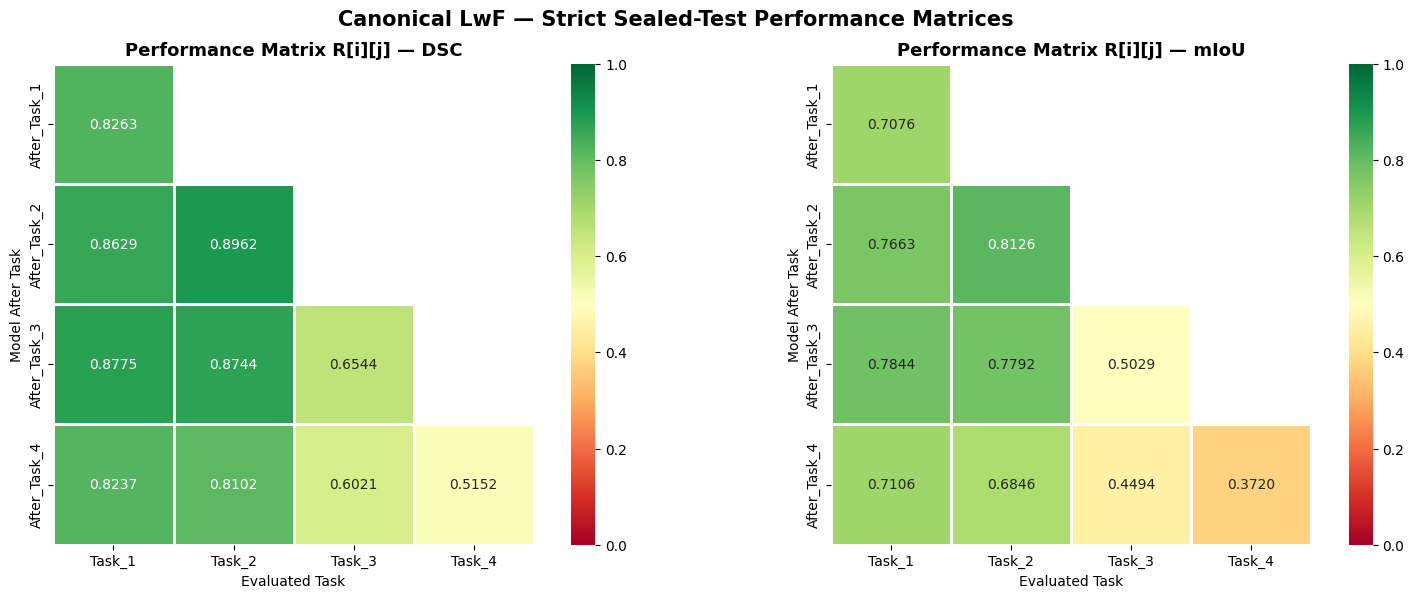


✓ Saved matrix visualization: /content/drive/MyDrive/Multi-Atlas_Labeling_Beyond_the_Cranial_Vault/logs_baseline/lwf_strict_R_matrices.png

  STRICT PERFORMANCE MATRIX ARTIFACTS COMPLETE
  JSON  : /content/drive/MyDrive/Multi-Atlas_Labeling_Beyond_the_Cranial_Vault/logs_baseline/lwf_strict_metrics.json
  CSV   : /content/drive/MyDrive/Multi-Atlas_Labeling_Beyond_the_Cranial_Vault/logs_baseline/lwf_R_matrix_DSC.csv
  CSV   : /content/drive/MyDrive/Multi-Atlas_Labeling_Beyond_the_Cranial_Vault/logs_baseline/lwf_R_matrix_mIoU.csv
  PLOT  : /content/drive/MyDrive/Multi-Atlas_Labeling_Beyond_the_Cranial_Vault/logs_baseline/lwf_strict_R_matrices.png
  split_checksum : 0d602a58da918c09
  config_hash    : 829c889fd5c875dc
  test  volumes  : ['img0033', 'img0037']
  val   volumes  : ['img0007', 'img0021', 'img0025', 'img0030']


In [ ]:
######################################################################
# PATCH — Step 7: Strict DSC & mIoU Performance Matrices
######################################################################

import os, json, hashlib, gc
from collections import defaultdict
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader

_required = {
    "CHECKPOINT_DIR": globals().get("CHECKPOINT_DIR"),
    "LOG_DIR":        globals().get("LOG_DIR"),
    "IMAGES_2D_DIR":  globals().get("IMAGES_2D_DIR"),
    "MASKS_2D_DIR":   globals().get("MASKS_2D_DIR"),
    "test_records_all": globals().get("test_records_all"),
    "TASK_ORGANS":    globals().get("TASK_ORGANS"),
    "ORGAN_NAMES":    globals().get("ORGAN_NAMES"),
    "TRAIN_CFG":      globals().get("TRAIN_CFG"),
    "IGNORE_INDEX":   globals().get("IGNORE_INDEX"),
    "DEVICE":         globals().get("DEVICE"),
    "BTCVDataset":    globals().get("BTCVDataset"),
    "build_unet":     globals().get("build_unet"),
    "force_cleanup":  globals().get("force_cleanup"),
    "test_vol_ids":   globals().get("test_vol_ids"),
    "val_vol_ids":    globals().get("val_vol_ids"),
}
_missing = [k for k, v in _required.items() if v is None]
if _missing:
    raise RuntimeError(
        f"[Step 7] Missing variables from earlier cells: {_missing}\n"
        "Run all cells from Step 1–6 before running Step 7."
    )
print("[Step 7] Dependency check passed ✓")

# ============================================================
def _sha256_file(path: str) -> str:
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(65536), b""):
            h.update(chunk)
    return h.hexdigest()[:16]


def _sha256_dict(d: dict) -> str:
    serialised = json.dumps(d, sort_keys=True).encode()
    return hashlib.sha256(serialised).hexdigest()[:16]


SPLIT_CHECKSUM = _sha256_file(
    os.path.join(
        os.path.dirname(IMAGES_2D_DIR.rstrip("/")),
        "volume_split.json"
    )
) if os.path.exists(
    os.path.join(os.path.dirname(IMAGES_2D_DIR.rstrip("/")), "volume_split.json")
) else "no_split_file"

_config_for_hash = {
    "encoder":      TRAIN_CFG["encoder"],
    "num_classes":  TRAIN_CFG["num_classes"],
    "batch_size":   TRAIN_CFG["batch_size"],
    "n_epochs":     TRAIN_CFG["n_epochs"],
    "lr":           TRAIN_CFG["lr"],
    "seed":         TRAIN_CFG["seed"],
    "ignore_index": IGNORE_INDEX,
    "task_organs":  {str(k): v for k, v in TASK_ORGANS.items()},
}
CONFIG_HASH = _sha256_dict(_config_for_hash)

print(f"SPLIT_CHECKSUM = {SPLIT_CHECKSUM}")
print(f"CONFIG_HASH    = {CONFIG_HASH}")

# ============================================================
def print_and_compute_cil_metrics(
    R: np.ndarray,
    metric_name: str = "DSC",
    task_organ_map: dict = None,
    organ_names_map: dict = None,
    num_tasks: int = 4,
) -> dict:
    """
    Parameters
    ----------
    R            : (num_tasks, num_tasks) ndarray, NaN for upper triangle.
    metric_name  : label used in print output ("DSC" or "mIoU").
    task_organ_map, organ_names_map : optional, used to print organ names.
    num_tasks    : number of tasks (default 4).

    Returns
    -------
    dict with keys: avg_accuracy, forgetting, bwt, last_row, diagonal.
    """
    T = num_tasks
    assert R.shape == (T, T), f"Expected ({T},{T}), got {R.shape}"

    print(f"\n{'='*65}")
    print(f"  CIL Metrics — {metric_name}")
    print(f"{'='*65}")

    # ── R matrix printout ──────────────────────────────────────────
    header = f"  {'':18s}" + "".join(f"  Task{j+1}" for j in range(T))
    print(header)
    print("  " + "-" * (18 + 7 * T))
    for i in range(T):
        row_label = f"After Task {i+1}"
        row_str = f"  {row_label:18s}"
        for j in range(T):
            v = R[i, j]
            row_str += f"  {v:.4f}" if not np.isnan(v) else "     — "
        print(row_str)
    print()

    # ── Diagonal: plasticity R[i,i] ───────────────────────────────
    diagonal = np.array([R[i, i] for i in range(T)])
    print(f"  Diagonal (plasticity):  "
          + "  ".join(f"{v:.4f}" for v in diagonal))

    # ── Last row: final model performance ─────────────────────────
    last_row = R[T - 1, :]
    valid_last = last_row[~np.isnan(last_row)]
    avg_accuracy = float(np.mean(valid_last)) if len(valid_last) > 0 else float("nan")
    print(f"  Avg Accuracy  (AA)    : {avg_accuracy:.4f}  "
          f"← mean of last row {[f'{v:.4f}' for v in last_row]}")

    # ── Forgetting: max past perf - final perf ────────────────────
    fgt_per_task = []
    for j in range(T - 1):   # exclude last task (no forgetting measured)
        past_perfs = [R[i, j] for i in range(j, T - 1) if not np.isnan(R[i, j])]
        if not past_perfs or np.isnan(R[T - 1, j]):
            continue
        fgt_j = max(past_perfs) - R[T - 1, j]
        fgt_per_task.append(fgt_j)
    forgetting = float(np.mean(fgt_per_task)) if fgt_per_task else float("nan")
    print(f"  Forgetting    (F)     : {forgetting:+.4f}")

    # ── Backward Transfer: R[T-1,j] - R[j,j] ────────────────────
    bwt_per_task = []
    for j in range(T - 1):
        if np.isnan(R[T - 1, j]) or np.isnan(R[j, j]):
            continue
        bwt_per_task.append(R[T - 1, j] - R[j, j])
    bwt = float(np.mean(bwt_per_task)) if bwt_per_task else float("nan")
    print(f"  Backward Transfer(BWT): {bwt:+.4f}")
    print(f"{'='*65}\n")

    return {
        "avg_accuracy": round(avg_accuracy, 4),
        "forgetting":   round(forgetting, 4),
        "bwt":          round(bwt, 4),
        "last_row":     [None if np.isnan(v) else round(float(v), 4) for v in last_row],
        "diagonal":     [round(float(v), 4) for v in diagonal],
    }
# ============================================================
def compute_strict_dsc_matrix(
    checkpoint_dir: str,
    test_records: list,
    images_dir: str,
    masks_dir: str,
    device,
    task_organ_map: dict,
    num_tasks: int = 4,
    num_classes: int = 14,
    encoder: str = "resnet34",
    ignore_index: int = 255,
    batch_size: int = 16,
    num_workers: int = 2,
) -> np.ndarray:
    """
    Compute R_dsc[i, j] = mean DSC of Task-j organs using model after Task i.
    Upper triangle (j > i) = NaN (task not yet learned).
    """
    R_dsc = np.full((num_tasks, num_tasks), np.nan)

    test_loader = DataLoader(
        BTCVDataset(test_records, images_dir, masks_dir,
                    task_id=None, augment=False),
        batch_size=batch_size, shuffle=False,
        num_workers=num_workers, pin_memory=False,
    )

    def get_ckpt_path(tid):
        candidates = []
        if tid == 1:
            candidates.append(f"{checkpoint_dir}/task1_best.pth")
        candidates += [
            f"{checkpoint_dir}/lwf_task{tid}_best_cil.pth",
            f"{checkpoint_dir}/lwf_task{tid}_best.pth",
        ]
        for p in candidates:
            if os.path.exists(p):
                return p
        return None

    for i in range(1, num_tasks + 1):
        ckpt_path = get_ckpt_path(i)
        if ckpt_path is None:
            print(f"  [WARN] No checkpoint for Task {i} — row {i} will be NaN")
            continue

        ckpt = torch.load(ckpt_path, map_location="cpu", weights_only=False)
        model = build_unet(
            num_classes=num_classes, encoder=encoder, pretrained=None
        ).to(device)
        model.load_state_dict(ckpt["model_state"])
        model.eval()
        print(f"  Task {i}: loaded {os.path.basename(ckpt_path)}")

        learned_organs = [
            o for t in range(1, i + 1) for o in task_organ_map[t]
        ]

        inter     = defaultdict(float)
        pred_sum  = defaultdict(float)
        true_sum  = defaultdict(float)

        with torch.no_grad():
            for ct_batch, mask_batch in test_loader:
                ct_batch   = ct_batch.to(device, non_blocking=True)
                mask_batch = mask_batch.to(device, non_blocking=True)
                with torch.amp.autocast("cuda", enabled=(device.type == "cuda")):
                    logits = model(ct_batch)
                pred  = torch.argmax(logits, dim=1)
                valid = (mask_batch != ignore_index)
                for oid in learned_organs:
                    pred_o = (pred      == oid) & valid
                    true_o = (mask_batch == oid) & valid
                    inter[oid]    += (pred_o & true_o).sum().item()
                    pred_sum[oid] += pred_o.sum().item()
                    true_sum[oid] += true_o.sum().item()

        for j in range(1, i + 1):
            dsc_j = []
            for oid in task_organ_map[j]:
                denom = pred_sum[oid] + true_sum[oid]
                if denom > 0:
                    dsc_j.append(2.0 * inter[oid] / denom)
            if dsc_j:
                R_dsc[i - 1, j - 1] = float(np.mean(dsc_j))

        del model, ckpt
        force_cleanup()

    return R_dsc
# ============================================================
def compute_strict_miou_matrix(
    checkpoint_dir: str,
    test_records: list,
    images_dir: str,
    masks_dir: str,
    device,
    task_organ_map: dict,
    num_tasks: int = 4,
    num_classes: int = 14,
    encoder: str = "resnet34",
    ignore_index: int = 255,
    batch_size: int = 16,
    num_workers: int = 2,
) -> np.ndarray:
    """
    Compute R_iou[i, j] = mean IoU of Task-j organs using model after Task i.
    Upper triangle (j > i) = NaN.
    """
    R_iou = np.full((num_tasks, num_tasks), np.nan)

    test_loader = DataLoader(
        BTCVDataset(test_records, images_dir, masks_dir,
                    task_id=None, augment=False),
        batch_size=batch_size, shuffle=False,
        num_workers=num_workers, pin_memory=False,
    )

    def get_ckpt_path(tid):
        candidates = []
        if tid == 1:
            candidates.append(f"{checkpoint_dir}/task1_best.pth")
        candidates += [
            f"{checkpoint_dir}/lwf_task{tid}_best_cil.pth",
            f"{checkpoint_dir}/lwf_task{tid}_best.pth",
        ]
        for p in candidates:
            if os.path.exists(p):
                return p
        return None

    for i in range(1, num_tasks + 1):
        ckpt_path = get_ckpt_path(i)
        if ckpt_path is None:
            print(f"  [WARN] No checkpoint for Task {i} — row {i} will be NaN")
            continue

        ckpt = torch.load(ckpt_path, map_location="cpu", weights_only=False)
        model = build_unet(
            num_classes=num_classes, encoder=encoder, pretrained=None
        ).to(device)
        model.load_state_dict(ckpt["model_state"])
        model.eval()
        print(f"  Task {i}: loaded {os.path.basename(ckpt_path)}")

        learned_organs = [
            o for t in range(1, i + 1) for o in task_organ_map[t]
        ]

        inter    = defaultdict(float)
        pred_sum = defaultdict(float)
        true_sum = defaultdict(float)

        with torch.no_grad():
            for ct_batch, mask_batch in test_loader:
                ct_batch   = ct_batch.to(device, non_blocking=True)
                mask_batch = mask_batch.to(device, non_blocking=True)
                with torch.amp.autocast("cuda", enabled=(device.type == "cuda")):
                    logits = model(ct_batch)
                pred  = torch.argmax(logits, dim=1)
                valid = (mask_batch != ignore_index)
                for oid in learned_organs:
                    pred_o = (pred      == oid) & valid
                    true_o = (mask_batch == oid) & valid
                    inter[oid]    += (pred_o & true_o).sum().item()
                    pred_sum[oid] += pred_o.sum().item()
                    true_sum[oid] += true_o.sum().item()

        for j in range(1, i + 1):
            ious_j = []
            for oid in task_organ_map[j]:
                union = pred_sum[oid] + true_sum[oid] - inter[oid]
                if union > 0:
                    ious_j.append(inter[oid] / union)
            if ious_j:
                R_iou[i - 1, j - 1] = float(np.mean(ious_j))

        del model, ckpt
        force_cleanup()

    return R_iou
# ============================================================
print("\n" + "="*65)
print("  Computing R_dsc_strict ...")
print("="*65)
R_dsc_strict = compute_strict_dsc_matrix(
    checkpoint_dir = CHECKPOINT_DIR,
    test_records   = test_records_all,
    images_dir     = IMAGES_2D_DIR,
    masks_dir      = MASKS_2D_DIR,
    device         = DEVICE,
    task_organ_map = TASK_ORGANS,
    num_tasks      = 4,
    num_classes    = TRAIN_CFG["num_classes"],
    encoder        = TRAIN_CFG["encoder"],
    ignore_index   = IGNORE_INDEX,
    batch_size     = TRAIN_CFG["batch_size"],
    num_workers    = TRAIN_CFG["num_workers"],
)

print("\n" + "="*65)
print("  Computing R_iou_strict ...")
print("="*65)
R_iou_strict = compute_strict_miou_matrix(
    checkpoint_dir = CHECKPOINT_DIR,
    test_records   = test_records_all,
    images_dir     = IMAGES_2D_DIR,
    masks_dir      = MASKS_2D_DIR,
    device         = DEVICE,
    task_organ_map = TASK_ORGANS,
    num_tasks      = 4,
    num_classes    = TRAIN_CFG["num_classes"],
    encoder        = TRAIN_CFG["encoder"],
    ignore_index   = IGNORE_INDEX,
    batch_size     = TRAIN_CFG["batch_size"],
    num_workers    = TRAIN_CFG["num_workers"],
)

# ── Print + compute CIL metrics ───────────────────────────────────────────────
metrics_dsc = print_and_compute_cil_metrics(R_dsc_strict, metric_name="DSC")
metrics_iou = print_and_compute_cil_metrics(R_iou_strict, metric_name="mIoU")
# ============================================================
def stable_json_hash(obj):
    import json, hashlib
    s = json.dumps(obj, sort_keys=True, separators=(",", ":"))
    return hashlib.sha256(s.encode("utf-8")).hexdigest()


def split_checksum(train_vol_ids, val_vol_ids, test_vol_ids=None):
    return stable_json_hash({
        "train_vol_ids": sorted([str(x) for x in train_vol_ids]),
        "val_vol_ids": sorted([str(x) for x in val_vol_ids]),
        "test_vol_ids": sorted([str(x) for x in (test_vol_ids or [])]),
    })
SPLIT_CHECKSUM = split_checksum(
    train_vol_ids,
    val_vol_ids,
    test_vol_ids,
)
CONFIG_HASH = config_hash(SPLIT_CHECKSUM)

strict_out = {
    "method": "CanonicalLwF",
    "eval_split": "sealed_test",
    "split_checksum": SPLIT_CHECKSUM,
    "config_hash": CONFIG_HASH,
    "R_dsc": R_dsc_strict.tolist(),
    "R_iou": R_iou_strict.tolist(),
    "metrics_dsc": metrics_dsc,
    "metrics_iou": metrics_iou,
}

strict_json = Path(LOG_DIR) / "lwf_strict_metrics.json"
with open(strict_json, "w") as f:
    json.dump(strict_out, f, indent=2)
print(f"\n✓ Saved JSON: {strict_json}")

# ============================================================
df_dsc = pd.DataFrame(
    R_dsc_strict,
    index   = [f"After_Task_{i}" for i in range(1, 5)],
    columns = [f"Task_{j}"       for j in range(1, 5)],
)
df_iou = pd.DataFrame(
    R_iou_strict,
    index   = [f"After_Task_{i}" for i in range(1, 5)],
    columns = [f"Task_{j}"       for j in range(1, 5)],
)

csv_dsc = Path(LOG_DIR) / "lwf_R_matrix_DSC.csv"
csv_iou = Path(LOG_DIR) / "lwf_R_matrix_mIoU.csv"
df_dsc.to_csv(csv_dsc)
df_iou.to_csv(csv_iou)
print(f"✓ Saved CSV DSC : {csv_dsc}")
print(f"✓ Saved CSV IoU : {csv_iou}")


# ============================================================
# VISUALIZATION — SIDE-BY-SIDE MATRICES
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, df, title in [
    (axes[0], df_dsc,  "Performance Matrix R[i][j] — DSC"),
    (axes[1], df_iou,  "Performance Matrix R[i][j] — mIoU"),
]:
    sns.heatmap(
        df,
        annot=True, fmt=".4f",
        cmap="RdYlGn", vmin=0, vmax=1,
        square=True, linewidths=1,
        ax=ax,
    )
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_xlabel("Evaluated Task")
    ax.set_ylabel("Model After Task")

plt.suptitle(
    "Canonical LwF — Strict Sealed-Test Performance Matrices",
    fontsize=15, fontweight="bold",
)
plt.tight_layout()

matrix_path = Path(LOG_DIR) / "lwf_strict_R_matrices.png"
plt.savefig(matrix_path, dpi=220, bbox_inches="tight")
plt.show()
print(f"\n✓ Saved matrix visualization: {matrix_path}")


# ============================================================
# FINAL SUMMARY
# ============================================================
print("\n" + "="*65)
print("  STRICT PERFORMANCE MATRIX ARTIFACTS COMPLETE")
print("="*65)
print(f"  JSON  : {strict_json}")
print(f"  CSV   : {csv_dsc}")
print(f"  CSV   : {csv_iou}")
print(f"  PLOT  : {matrix_path}")
print(f"  split_checksum : {SPLIT_CHECKSUM}")
print(f"  config_hash    : {CONFIG_HASH}")
print(f"  test  volumes  : {sorted(test_vol_ids)}")
print(f"  val   volumes  : {sorted(val_vol_ids)}")
print("="*65)

## Appendix — Canonical LwF Audit Checklist

| # | Requirement | Status | Where verified |
|---|-------------|--------|----------------|
| A1 | **Teacher frozen**: `.eval()` + `requires_grad=False` | ✅ | `LwFTrainer.__init__` — assert verified |
| A2 | **Teacher inference in `torch.no_grad()`** | ✅ | `train_epoch` — explicit `with torch.no_grad()` |
| A3 | **Teacher is deepcopy** — decoupled from student | ✅ | `copy.deepcopy(model)` before Task t training |
| A4 | **No stale/cached logits** — teacher queried live per batch | ✅ | No pre-generated targets file |
| A5 | **No multi-teacher** — single teacher per task | ✅ | One deepcopy, one teacher throughout task |
| A6 | **KD active and logged**: kd_loss, seg_loss, kd/seg ratio | ✅ | `train_epoch` return values, `fit` prints |
| A7 | **KD warns if inactive**: ratio < 0.1 or > 10 | ✅ | `fit` prints WARN |
| A8 | **Val/Test separation**: test_loader never passed to trainer | ✅ | `fit` receives `val_eval_loader`, not `test_loader` |
| A9 | **Checkpoint lưu**: model, optimizer, scheduler, epoch, task, seed, config | ✅ | `save_checkpoint` state dict |
| A10 | **Volume-level split** (no slice-level leakage) | ✅ | `create_three_way_split` + assert no overlap |
| A11 | **Forgetting NaN documented** | ✅ | `compute_forgetting` docstring |
| A12 | **Seed control**: random, numpy, torch, cuda, DataLoader workers | ✅ | `set_global_seed`, `seed_worker` |
| A13 | **Run from clean kernel** | ✅ | No cell-order dependency, no external notebook |
| A14 | **Performance matrix on TEST set** | ✅ | `compute_performance_matrix_on_test` |

### Known Deviations from Li & Hoiem (2016) — Documented

1. **Shared head** (class-incremental): Original LwF uses task-specific heads.  
   Adaptation reason: CIL segmentation requires a single unified prediction head.  
   → *Report as: "shared-head CIL variant of LwF"*

2. **Background shift** (Cermelli et al., CVPR 2020): Teacher's background channel  
   absorbs probability mass from future organs not yet learned.  
   Not fixed in this baseline — this is the known LwF limitation for CIL segmentation.  
   → *Report in Section 4 Limitations. Refer to MiB for the fix.*

3. **2D slices** (dataset adaptation): Evaluation on 2D CT slices vs 3D volumes.  
   Metrics may differ from BTCV leaderboard (3D evaluation).  
   → *Report in Experimental Setup.*